# Question A1 (15 marks)

#### Design a feedforward deep neural network (DNN) which consists of **three** hidden layers of 128 neurons each with ReLU activation function, and an output layer with sigmoid activation function. Apply dropout of probability **0.3** to each of the hidden layers.

In [3]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed

### Predefined Values

In [5]:
no_labels = 1
no_features = 77
hidden_layers = [128, 128, 128]

dropout_rate = 0.3

no_of_epochs = 200

learning_rate = 0.0005
weight_decay = 0.0005
early_stopping_patience = 5
batch_size = 64

seed = 42
set_seed(seed)

#### 1.Define the model class.

In [7]:
class MLP(nn.Module):
    def __init__(self, no_features, hidden_layers, no_labels, dropout_rate):
        super().__init__()
        layers = []
        input_size = no_features

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_rate))
            input_size = hidden_size

        layers.append(nn.Linear(input_size, no_labels))
        layers.append(nn.Sigmoid())

        self.mlp_stack = nn.Sequential(*layers)

    #Feed Forward Function
    def forward(self, x):
        logits = self.mlp_stack(x)
        return logits

#### Divide the dataset into a 75:25 ratio for training and testing. Use **appropriate** scaling of input features. We solely assume that there are only two datasets here: training & test.

#### 2.Split the dataset and do preprocessing.

In [10]:
from common_utils import split_dataset, preprocess_dataset


def preprocess(df):
    x_train, y_train, x_test, y_test = split_dataset(df = df, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)

    X_train_scaled, X_test_scaled = preprocess_dataset(x_train, x_test)
    
    return X_train_scaled, y_train, X_test_scaled, y_test

df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train_scaled, y_train, X_test_scaled, y_test = preprocess(df)

In [11]:
df['label'].value_counts()

label
1    6202
0    5855
Name: count, dtype: int64

#### Use the training dataset to train the model for 200 epochs. Use a mini-batch gradient descent with **‘Adam’** optimizer with learning rate of **0.0005**, weight decay of **0.0005** and **batch size = 64**. Implement early stopping with patience of **5**.

#### 3.Define a Pytorch Dataset and Dataloaders.  

In [14]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


def intialise_loaders(X_train_scaled, y_train, X_test_scaled, y_test):
    
    train_dataset = CustomDataset(X_train_scaled, y_train)
    test_dataset  = CustomDataset(X_test_scaled, y_test)

    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    return train_dataloader, test_dataloader

train_dataloader, test_dataloader = intialise_loaders(X_train_scaled, y_train, X_test_scaled, y_test)

In [15]:
#verify the data loader works and size of the data loader
X_batch, y_batch = next(iter(train_dataloader))
print(X_batch.shape)  # (32, num_features)
print(y_batch.shape)  # (32,)

torch.Size([64, 77])
torch.Size([64])


#### 4.Next, define the model, optimizer and loss function.

In [17]:
from common_utils import EarlyStopper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(no_features=no_features, hidden_layers=hidden_layers, no_labels=no_labels, dropout_rate=dropout_rate).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_fn = nn.BCELoss()

print(model)

#initialize the early stopping
early_stopper = EarlyStopper(patience=early_stopping_patience, min_delta=0)

MLP(
  (mlp_stack): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


#### 5.Train model for 200 epochs. Record down train and test accuracies. Implement early stopping.

In [22]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, train_correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        X, y = X.to(device), y.to(device)  # ← move data to same device as model
        
        # Compute prediction and loss
        pred = model(X).squeeze(1)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_correct += ((pred >= 0.5).float() == y).type(torch.float).sum().item()
    
    train_loss /= size
    train_correct /=size

    return train_loss, train_correct

def test_loop(dataloader, model, loss_fn):
    
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            X, y = X.to(device), y.to(device)  # ← move data to same device as model
            
            pred = model(X).squeeze(1)
            test_loss += loss_fn(pred, y).item()
            test_correct += ((pred >= 0.5).float() == y).type(torch.float).sum().item()

    test_loss /= size
    test_correct /= size
    
    return test_loss, test_correct

In [24]:
tr_loss, tr_correct = [], []
te_loss, te_correct = [], []

for t in range(no_of_epochs):
    train_loss, train_correct = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_correct = test_loop(test_dataloader, model, loss_fn)
    
    tr_loss.append(train_loss), tr_correct.append(train_correct)
    te_loss.append(test_loss), te_correct.append(test_correct)
    
    
    print(f"Epoch {t+1}: Train_accuracy: {(100*train_correct):>0.2f}%, Train_loss: {train_loss:>8f}, Test_accuracy: {(100*test_correct):>0.2f}%, Test_loss: {test_loss:>8f}")
    
    if early_stopper.early_stop(test_loss): 
        print("Done!")
        break

Epoch 1: Train_accuracy: 57.96%, Train_loss: 0.010580, Test_accuracy: 58.97%, Test_loss: 0.010594
Epoch 2: Train_accuracy: 59.41%, Train_loss: 0.010440, Test_accuracy: 60.46%, Test_loss: 0.010459
Epoch 3: Train_accuracy: 61.69%, Train_loss: 0.010268, Test_accuracy: 60.93%, Test_loss: 0.010372
Epoch 4: Train_accuracy: 62.30%, Train_loss: 0.010125, Test_accuracy: 61.06%, Test_loss: 0.010365
Epoch 5: Train_accuracy: 63.49%, Train_loss: 0.009988, Test_accuracy: 62.22%, Test_loss: 0.010344
Epoch 6: Train_accuracy: 64.82%, Train_loss: 0.009847, Test_accuracy: 62.52%, Test_loss: 0.010227
Epoch 7: Train_accuracy: 65.53%, Train_loss: 0.009707, Test_accuracy: 63.48%, Test_loss: 0.010032
Epoch 8: Train_accuracy: 66.37%, Train_loss: 0.009540, Test_accuracy: 63.78%, Test_loss: 0.010161
Epoch 9: Train_accuracy: 67.24%, Train_loss: 0.009436, Test_accuracy: 63.08%, Test_loss: 0.010110
Epoch 10: Train_accuracy: 67.86%, Train_loss: 0.009324, Test_accuracy: 65.14%, Test_loss: 0.009951
Epoch 11: Train_acc

#### Plot train and test accuracies and losses on training and test data against training epochs and comment on the line plots.


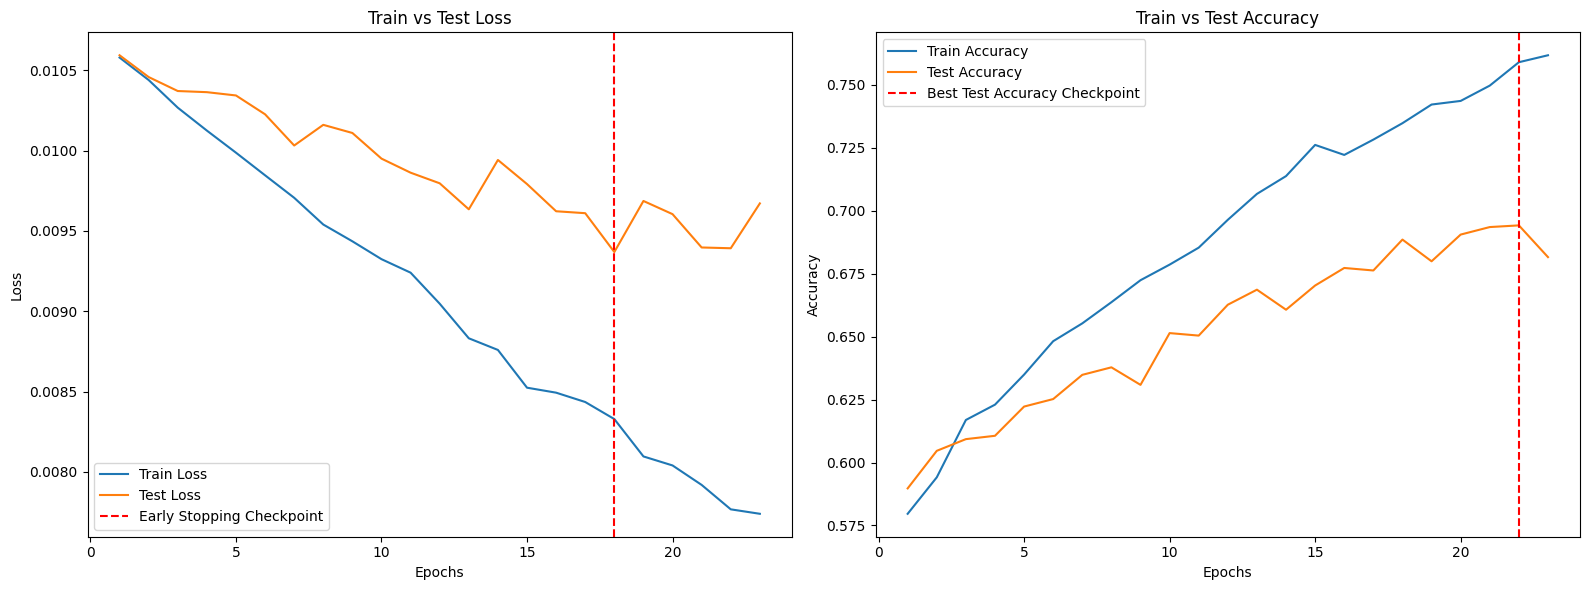

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Loss Plot ──────────────────────────────────────
ax1.plot(range(1, len(tr_loss)+1), tr_loss, label='Train Loss')
ax1.plot(range(1, len(te_loss)+1), te_loss, label='Test Loss')
minposs = te_loss.index(min(te_loss)) + 1
ax1.axvline(minposs, linestyle='--', color='r', label='Early Stopping Checkpoint')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Train vs Test Loss')
ax1.legend()

# ── Accuracy Plot ──────────────────────────────────
ax2.plot(range(1, len(tr_correct)+1), tr_correct, label='Train Accuracy')
ax2.plot(range(1, len(te_correct)+1), te_correct, label='Test Accuracy')
maxposs = te_correct.index(max(te_correct)) + 1
ax2.axvline(maxposs, linestyle='--', color='r', label='Best Test Accuracy Checkpoint')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

6.Comment on line plots.

In [29]:
# YOUR CODE HERE
answer = """
For the "Train vs Test Loss" graph, it shows that before epoch 18, the model is learning, where both train and test loss are decreasing steadily. Since the train loss drops faster than the validation loss, suggesting the model is slightly overfitting. It also shows that the early stopping function works perfectly, as it stops the training after the testing loss starts to increase and prevents overfitting the model.

For the "Train vs Test Accuracy" graph, it shows that before epoch 22, both train and test accuracy are increasing steadily, which is a good sign for the model. However, the significant increase of the gap between train and test confirms that the model is overfitting, as the model starts to memorize the training data but does not generalize perfectly.
"""

print(answer)


For the "Train vs Test Loss" graph, it shows that before epoch 18, the model is learning, where both train and test loss are decreasing steadily. Since the train loss drops faster than the validation loss, suggesting the model is slightly overfitting. It also shows that the early stopping function works perfectly, as it stops the training after the testing loss starts to increase and prevents overfitting the model.

For the "Train vs Test Accuracy" graph, it shows that before epoch 22, both train and test accuracy are increasing steadily, which is a good sign for the model. However, the significant increase of the gap between train and test confirms that the model is overfitting, as the model starts to memorize the training data but does not generalize perfectly.

